In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ####################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder

# 학습 모델 성능 관련 ####################################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 모델 성능평가 #############################################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score

### 오차행렬

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

In [3]:
# 데이터를 불러온다.
data = load_breast_cancer()
X = data.data
y= data.target

In [4]:
# 학습용과 검증용으로 나눈다.
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [5]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [6]:
# 오차 행렬을 구한다.
cm = confusion_matrix(y_test, y_pred)
cm

array([[39,  4],
       [ 1, 70]])

In [7]:
cm_df = pd.DataFrame(cm, columns=['예측(N)', '예측(P)'], index=['실제(N)','실제(P)'])
cm_df

,예측(N),예측(P)
실제(N),39,4
실제(P),1,70


Text(116.72222222222221, 0.5, '실제 정답')

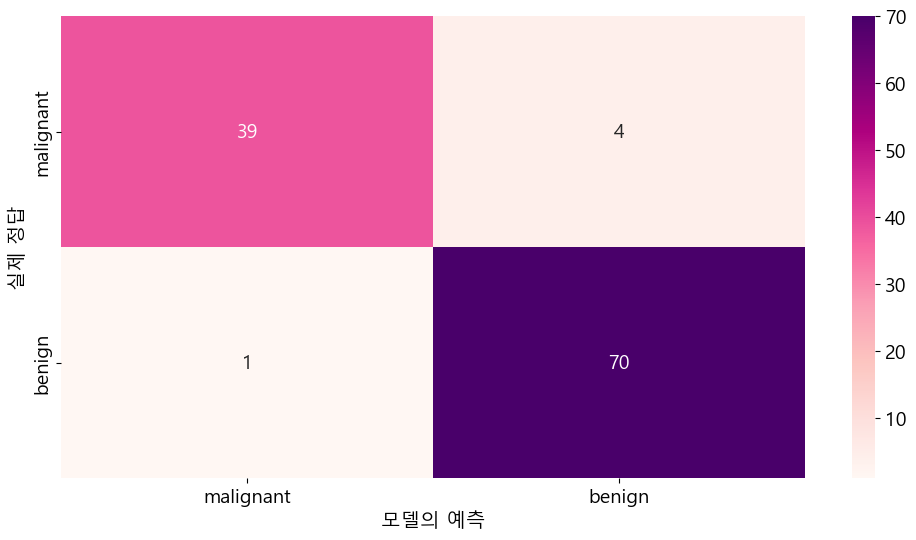

In [8]:
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('모델의 예측')
plt.ylabel('실제 정답')

### 2진 분류의 평가지표
- 정밀도(Precision) : FP를 줄이는게 중요한 프로젝트에서 사용
- 재현율(Recall) : FN을 줄이는게 중요한 프로젝트에서 사용
- F1-Score : 조화 평균, 정밀도와 재현율이 얼마나 비슷한지 확인. 정밀도와 재현율이 비슷하면 높게 나오고 서로 많이 다르면 0과 가깝게 나온다. FP와 FN 모두 줄이는게 중요한 프로젝트에서 사용 (대부분의 프로젝트에 해당)

In [9]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

In [10]:
data = load_breast_cancer()
x = data.data
y= data.target

In [11]:
# 학습용과 테스트용으로 나눈다
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [12]:
#학습과 예측
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [13]:
# 주요 평가지표
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print(f'정밀도 : {precision:.4f}')
print(f'재현율 : {recall:.4f}')
print(f'F1-Score : {f1:.4f}')

정밀도 : 0.9459
재현율 : 0.9859
F1-Score : 0.9655


- 정밀도가 1과 매우 가깝기 때문에 FP가 매우적음을 알 수 있다.
- 재현율이 1과 매우 가깝기 때문에 FN이 매우적음을 알 수 있다.
- F1-Score가 매우 높기 떄문에 정밀도와 재현율이 서로 비슷하고 1과 가깝기 때문에 FP,FN 모두 적음을 알 수 있다.

### ROC 곡선과 AUC

In [14]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

In [15]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [16]:
model = LogisticRegression(max_iter = 10000)
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
y_probs = model.predict_proba(X_test)[:,1]
y_probs 

array([8.78761734e-01, 3.03624981e-08, 1.59490988e-03, 9.98786462e-01,
       9.99860203e-01, 1.94458720e-10, 6.09483521e-11, 1.92268979e-02,
       9.84147966e-01, 9.94369705e-01, 9.29567876e-01, 8.06714616e-04,
       9.88982871e-01, 1.75825070e-01, 9.99220747e-01, 1.72757217e-03,
       9.98818067e-01, 9.99988152e-01, 9.99999400e-01, 7.11997904e-07,
       8.28359118e-01, 9.92360348e-01, 6.05567114e-09, 9.99667164e-01,
       9.96561676e-01, 9.99761544e-01, 9.98986192e-01, 9.98987461e-01,
       9.95341525e-01, 7.24261984e-09, 9.98547396e-01, 9.99765490e-01,
       9.99115867e-01, 9.86528976e-01, 9.99885230e-01, 9.99063309e-01,
       2.06965255e-03, 9.98997348e-01, 1.00498018e-05, 7.19277990e-01,
       9.99784959e-01, 6.20197640e-04, 9.99543679e-01, 9.96045992e-01,
       9.99760363e-01, 9.82995181e-01, 9.99968358e-01, 9.99527353e-01,
       9.59614573e-01, 9.98588227e-01, 9.42215030e-05, 2.87775912e-09,
       8.61104993e-01, 9.99612047e-01, 9.99403731e-01, 9.86240617e-01,
      

In [18]:
# roc 곡선을 위한 값을 가져온다.
FPR, TPR, thresholds = roc_curve(y_test, y_probs)

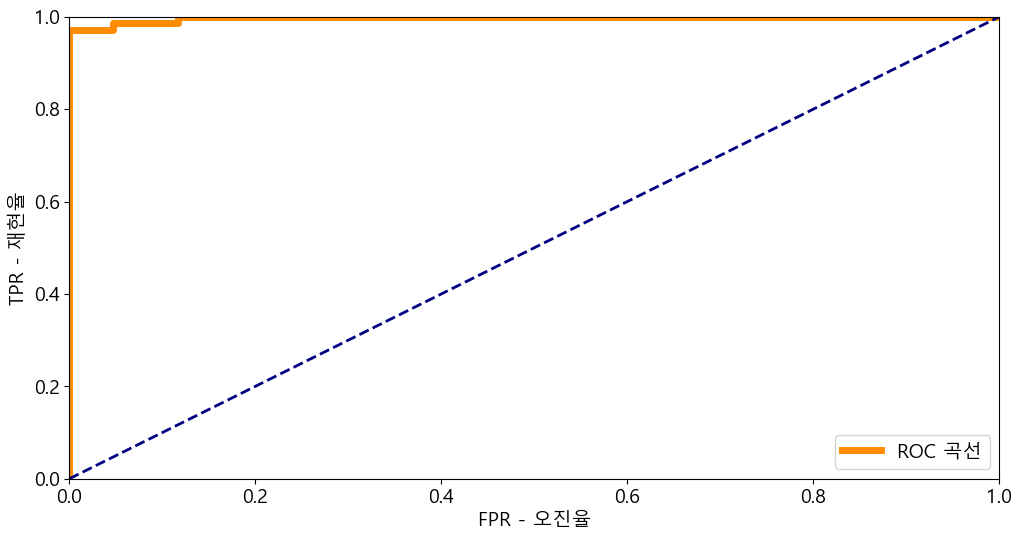

In [19]:
plt.plot(FPR, TPR, color='darkorange', lw =5, label='ROC 곡선')
plt.plot([0,1],[0,1], color='navy', lw = 2 , linestyle='--')
plt.xlim(0.0,1.0)
plt.ylim(0.0,1.0)
plt.xlabel('FPR - 오진율')
plt.ylabel('TPR - 재현율')
plt.legend()
plt.show()

In [20]:
# auc 계산
roc_auc = auc(FPR,TPR)
roc_auc

0.9977071732721913

In [21]:
# auc 값만 알면 된다면
roc_auc2 = roc_auc_score(y_test, y_probs)
roc_auc2

0.9977071732721913

### 다중 분류

In [22]:
from sklearn.datasets import load_iris

In [23]:
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data,iris.target, test_size=0.3, random_state=42)

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [26]:
macro_avg = f1_score(y_test, y_pred, average='macro')
weight_avg = f1_score(y_test, y_pred, average='weighted')
micro_avg = f1_score(y_test, y_pred, average='micro')
accuracy = f1_score(y_test, y_pred, average= 'micro')

print(f'macro avg : {macro_avg}')
print(f'weight avg : {weight_avg}')
print(f'micro avg : {micro_avg}')
print(f'정확도 : {accuracy}')

macro avg : 1.0
weight avg : 1.0
micro avg : 1.0
정확도 : 1.0


- macro avg : 전체 결과 데이터 중 특정 클래스의 수가 매우 적을 때 그 데이터를 잘 맞췄는지 확인하는 용도이다.
- 1.0 이므로 적은 비율을 차지하는 데이터를 잘 맞춘 것으로 평가할 수 있다.
  
- weighted avg : 각 결과 데이터의 비율에 따른 가중치를 부여하여 각각 안에서 얼마나 잘 맞추는지 확인하는 용도
- 1.0이므로 각 클래스 별로 맞추는 수준이 비슷하며 매우 잘 맞춘다.
  
- micro avg : 단순히 정답을 얼마나 맞췄는지(accuracy)

In [27]:
# 다중 분류에서도 오차행렬을 구할 수 있다
cm = confusion_matrix(y_test, y_pred)
cm

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

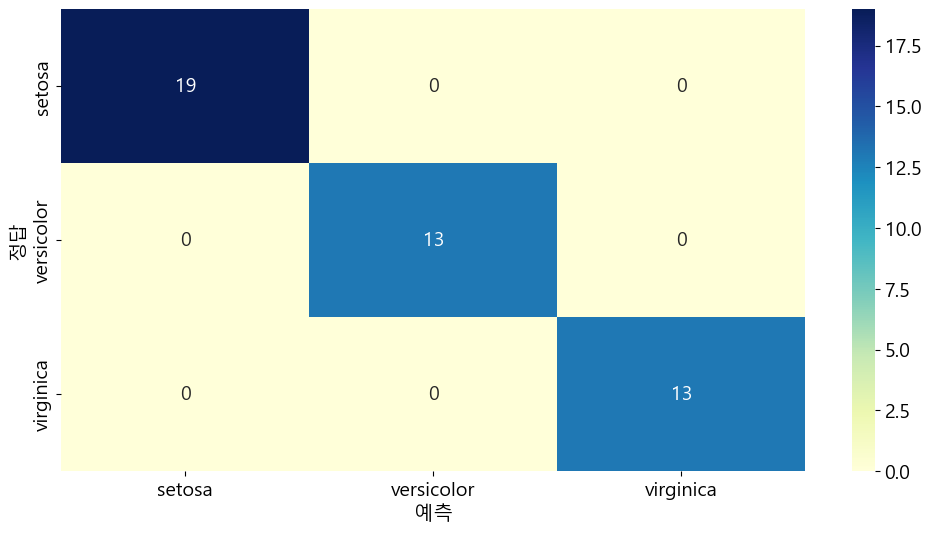

In [30]:
sns.heatmap(cm, annot  = True, fmt ='d', cmap='YlGnBu',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('예측')
plt.ylabel('정답')
plt.show()